In [7]:
# Uninstall potentially conflicting packages (e.g., newer TensorFlow/Keras versions)
!pip uninstall -y tensorflow keras

# Install TensorFlow (latest compatible version)
!pip install tensorflow

Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
Found existing installation: keras 3.13.2
Uninstalling keras-3.13.2:
  Successfully uninstalled keras-3.13.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB ? eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 137.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 34.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the follo

In [23]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lgg-mri-segmentation' dataset.
Path to dataset files: /kaggle/input/lgg-mri-segmentation


In [24]:
import os

dataset_files = os.listdir(path)
print(f"Files in the dataset directory: {dataset_files}")

Files in the dataset directory: ['kaggle_3m', 'lgg-mri-segmentation']


In [25]:
lgg_mri_segmentation_path = os.path.join(path, 'lgg-mri-segmentation')
lgg_mri_segmentation_files = os.listdir(lgg_mri_segmentation_path)
print(f"Files in lgg-mri-segmentation directory: {lgg_mri_segmentation_files[:5]} (showing first 5 files)")
print(f"Total files: {len(lgg_mri_segmentation_files)}")

Files in lgg-mri-segmentation directory: ['kaggle_3m'] (showing first 5 files)
Total files: 1


In [26]:
kaggle_3m_path = os.path.join(lgg_mri_segmentation_path, 'kaggle_3m')
kaggle_3m_files = os.listdir(kaggle_3m_path)
print(f"Files in kaggle_3m directory: {kaggle_3m_files[:5]} (showing first 5 files)")
print(f"Total files: {len(kaggle_3m_files)}")

Files in kaggle_3m directory: ['TCGA_DU_7010_19860307', 'TCGA_DU_8162_19961029', 'TCGA_FG_A4MT_20020212', 'TCGA_FG_5964_20010511', 'TCGA_DU_A5TS_19970726'] (showing first 5 files)
Total files: 112


In [12]:
first_patient_folder = kaggle_3m_files[0]
first_patient_path = os.path.join(kaggle_3m_path, first_patient_folder)
first_patient_contents = os.listdir(first_patient_path)
print(f"Contents of the first patient folder '{first_patient_folder}': {first_patient_contents}")

Contents of the first patient folder 'TCGA_DU_7010_19860307': ['TCGA_DU_7010_19860307_45.tif', 'TCGA_DU_7010_19860307_56_mask.tif', 'TCGA_DU_7010_19860307_57.tif', 'TCGA_DU_7010_19860307_33.tif', 'TCGA_DU_7010_19860307_27.tif', 'TCGA_DU_7010_19860307_52.tif', 'TCGA_DU_7010_19860307_10.tif', 'TCGA_DU_7010_19860307_8_mask.tif', 'TCGA_DU_7010_19860307_34_mask.tif', 'TCGA_DU_7010_19860307_33_mask.tif', 'TCGA_DU_7010_19860307_29.tif', 'TCGA_DU_7010_19860307_43_mask.tif', 'TCGA_DU_7010_19860307_39_mask.tif', 'TCGA_DU_7010_19860307_56.tif', 'TCGA_DU_7010_19860307_7_mask.tif', 'TCGA_DU_7010_19860307_24.tif', 'TCGA_DU_7010_19860307_9.tif', 'TCGA_DU_7010_19860307_31_mask.tif', 'TCGA_DU_7010_19860307_7.tif', 'TCGA_DU_7010_19860307_37.tif', 'TCGA_DU_7010_19860307_49.tif', 'TCGA_DU_7010_19860307_6_mask.tif', 'TCGA_DU_7010_19860307_6.tif', 'TCGA_DU_7010_19860307_38_mask.tif', 'TCGA_DU_7010_19860307_51_mask.tif', 'TCGA_DU_7010_19860307_16.tif', 'TCGA_DU_7010_19860307_34.tif', 'TCGA_DU_7010_19860307_1

In [13]:
image_files = [f for f in first_patient_contents if not f.endswith('_mask.tif')]
mask_files = [f for f in first_patient_contents if f.endswith('_mask.tif')]

print(f"Number of image files: {len(image_files)}")
print(f"Number of mask files: {len(mask_files)}")
print(f"Example image file: {image_files[0] if image_files else 'N/A'}")
print(f"Example mask file: {mask_files[0] if mask_files else 'N/A'}")

Number of image files: 58
Number of mask files: 58
Example image file: TCGA_DU_7010_19860307_45.tif
Example mask file: TCGA_DU_7010_19860307_56_mask.tif


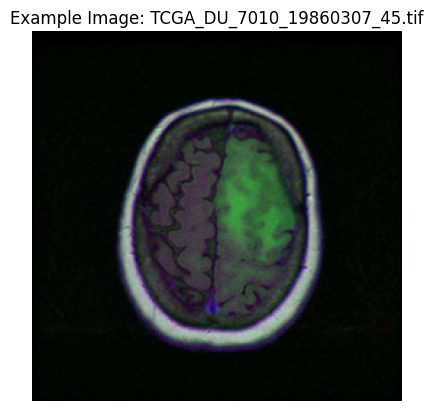

Image size: (256, 256)
Image mode: RGB


In [14]:
from PIL import Image
import matplotlib.pyplot as plt

# Construct the full path to the first image file
example_image_path = os.path.join(first_patient_path, image_files[0])

# Open the image
image = Image.open(example_image_path)

# Display the image
plt.imshow(image)
plt.title(f"Example Image: {image_files[0]}")
plt.axis('off')
plt.show()

print(f"Image size: {image.size}")
print(f"Image mode: {image.mode}")

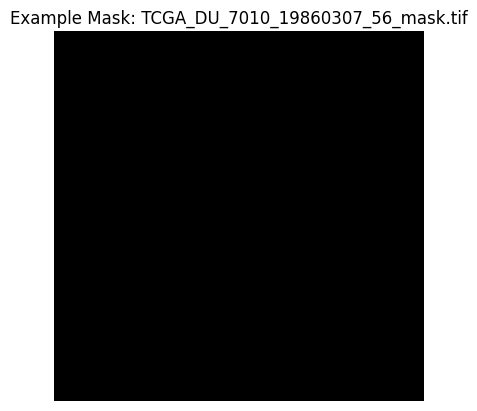

Mask size: (256, 256)
Mask mode: L


In [15]:
# Construct the full path to the first mask file
example_mask_path = os.path.join(first_patient_path, mask_files[0])

# Open the mask
mask = Image.open(example_mask_path)

# Display the mask
plt.imshow(mask, cmap='gray') # Masks are typically grayscale
plt.title(f"Example Mask: {mask_files[0]}")
plt.axis('off')
plt.show()

print(f"Mask size: {mask.size}")
print(f"Mask mode: {mask.mode}")

In [27]:
from sklearn.model_selection import train_test_split
import random

# Seed for reproducibility
random.seed(42)

# Shuffle the patient folders
random.shuffle(kaggle_3m_files)

# Define split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Split patient folders into train, validation, and test sets
train_patients, temp_patients = train_test_split(kaggle_3m_files, test_size=(val_ratio + test_ratio), random_state=42)
val_patients, test_patients = train_test_split(temp_patients, test_size=(test_ratio / (val_ratio + test_ratio)), random_state=42)

print(f"Number of training patients: {len(train_patients)}")
print(f"Number of validation patients: {len(val_patients)}")
print(f"Number of test patients: {len(test_patients)}")

Number of training patients: 78
Number of validation patients: 17
Number of test patients: 17


In [28]:
def get_image_mask_paths(patient_list, base_path):
    image_paths = []
    mask_paths = []
    for patient_folder in patient_list:
        patient_path = os.path.join(base_path, patient_folder)
        # Check if the path is actually a directory before listing its contents
        if os.path.isdir(patient_path):
            files_in_patient_folder = os.listdir(patient_path)
            for f in files_in_patient_folder:
                if f.endswith('.tif') and not f.endswith('_mask.tif'):
                    image_paths.append(os.path.join(patient_path, f))
                elif f.endswith('_mask.tif'):
                    mask_paths.append(os.path.join(patient_path, f))
        else:
            # Print a message for debugging/information if a non-directory is found
            print(f"Skipping non-directory item: {patient_path}")
    return image_paths, mask_paths

train_image_paths, train_mask_paths = get_image_mask_paths(train_patients, kaggle_3m_path)
val_image_paths, val_mask_paths = get_image_mask_paths(val_patients, kaggle_3m_path)
test_image_paths, test_mask_paths = get_image_mask_paths(test_patients, kaggle_3m_path)

print(f"Total training images: {len(train_image_paths)}")
print(f"Total training masks: {len(train_mask_paths)}")
print(f"Total validation images: {len(val_image_paths)}")
print(f"Total validation masks: {len(val_mask_paths)}")
print(f"Total test images: {len(test_image_paths)}")
print(f"Total test masks: {len(test_mask_paths)}")

Skipping non-directory item: /kaggle/input/lgg-mri-segmentation/lgg-mri-segmentation/kaggle_3m/README.md
Skipping non-directory item: /kaggle/input/lgg-mri-segmentation/lgg-mri-segmentation/kaggle_3m/data.csv
Total training images: 2829
Total training masks: 2829
Total validation images: 567
Total validation masks: 567
Total test images: 533
Total test masks: 533


## Preprocessing



In [41]:
import numpy as np
from PIL import Image

def preprocess_image_mask(image_path, mask_path, target_size=(256, 256)):
    """
    Loads an image and its corresponding mask, resizes them (if necessary),
    converts them to NumPy arrays, and normalizes the image pixels.

    Args:
        image_path (str): Path to the image file.
        mask_path (str): Path to the mask file.
        target_size (tuple): Desired (height, width) for resizing.

    Returns:
        tuple: A tuple containing the preprocessed image array and mask array.
    """
    # Load image
    image = Image.open(image_path).resize(target_size)
    image = np.array(image, dtype=np.float32) / 255.0  # Normalize to [0, 1] and cast to float32

    # Load mask
    mask = Image.open(mask_path).resize(target_size)
    # Convert mask to binary (0 or 1). Assuming masks are grayscale and tumor is non-zero.
    mask = np.array(mask, dtype=np.float32) / 255.0 # Cast to float32
    mask[mask > 0] = 1 # Binarize the mask
    mask = np.expand_dims(mask, axis=-1) # Add channel dimension (H, W, 1)

    return image, mask

print("Preprocessing function 'preprocess_image_mask' defined.")

Preprocessing function 'preprocess_image_mask' defined.


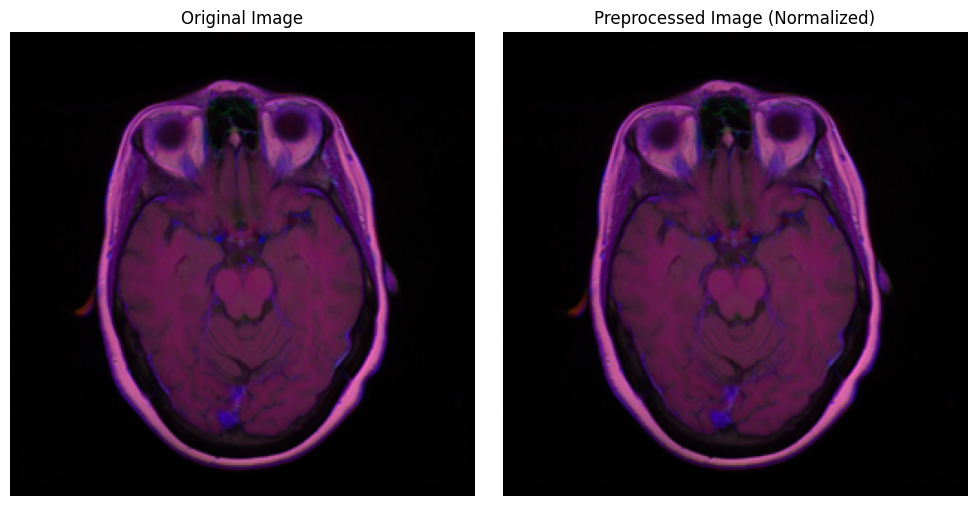

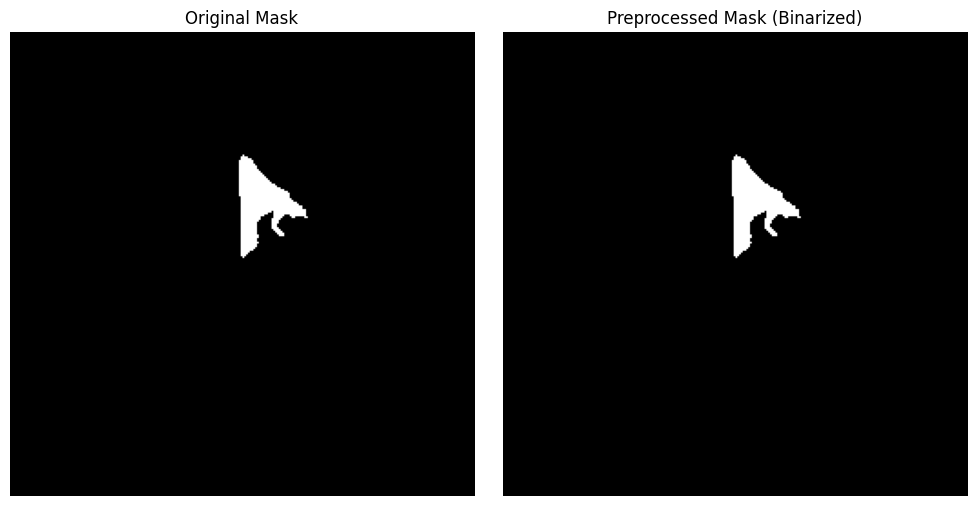

Preprocessed Image shape: (256, 256, 3), dtype: float32
Preprocessed Mask shape: (256, 256, 1), dtype: float32


In [42]:
import matplotlib.pyplot as plt

# Get an example from the training set
example_train_image_path = train_image_paths[0]
example_train_mask_path = train_mask_paths[0]

# Preprocess the example
preprocessed_image, preprocessed_mask = preprocess_image_mask(example_train_image_path, example_train_mask_path)

# Display the original and preprocessed versions for verification
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original Image (for comparison, loading it again)
original_image = Image.open(example_train_image_path)
axes[0].imshow(original_image)
axes[0].set_title('Original Image')
axes[0].axis('off')

# Preprocessed Image (normalized)
axes[1].imshow(preprocessed_image)
axes[1].set_title('Preprocessed Image (Normalized)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original Mask (for comparison, loading it again)
original_mask = Image.open(example_train_mask_path)
axes[0].imshow(original_mask, cmap='gray')
axes[0].set_title('Original Mask')
axes[0].axis('off')

# Preprocessed Mask (binarized)
axes[1].imshow(preprocessed_mask, cmap='gray')
axes[1].set_title('Preprocessed Mask (Binarized)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Preprocessed Image shape: {preprocessed_image.shape}, dtype: {preprocessed_image.dtype}")
print(f"Preprocessed Mask shape: {preprocessed_mask.shape}, dtype: {preprocessed_mask.dtype}")

## Data Augmentation



In [43]:
import tensorflow as tf
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def augment_data(image, mask):
    """
    Applies data augmentation to an image and its corresponding mask.

    Args:
        image (np.array): The input image as a NumPy array (H, W, C).
        mask (np.array): The corresponding mask as a NumPy array (H, W, 1).

    Returns:
        tuple: A tuple containing the augmented image and mask arrays, both with channel dimension.
    """
    # Convert to TensorFlow tensors and add batch dimension
    image = tf.expand_dims(image, axis=0) # (1, H, W, C)
    mask = tf.expand_dims(mask, axis=0)   # (1, H, W, 1)

    # Random horizontal flip
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    # Random vertical flip
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    # Random rotation (up to 45 degrees)
    angle = tf.random.uniform(shape=[], minval=-0.25 * np.pi, maxval=0.25 * np.pi)

    # Apply affine transform. image[0] and mask[0] are (H, W, C) and (H, W, 1) respectively.
    # Ensure channel_axis is correctly set for both.
    image = tf.keras.preprocessing.image.apply_affine_transform(image[0].numpy(), theta=np.degrees(angle), row_axis=0, col_axis=1, channel_axis=2, fill_mode='nearest')
    mask = tf.keras.preprocessing.image.apply_affine_transform(mask[0].numpy(), theta=np.degrees(angle), row_axis=0, col_axis=1, channel_axis=2, fill_mode='nearest')

    # The affine transform returns a numpy array, convert back to tf.tensor and add batch dim
    image = tf.expand_dims(tf.convert_to_tensor(image, dtype=tf.float32), axis=0)
    mask = tf.expand_dims(tf.convert_to_tensor(mask, dtype=tf.float32), axis=0)

    # Remove batch dimension before returning, keeping the channel dimension for mask
    return image[0], mask[0]

print("Data augmentation function 'augment_data' defined.")

Data augmentation function 'augment_data' defined.


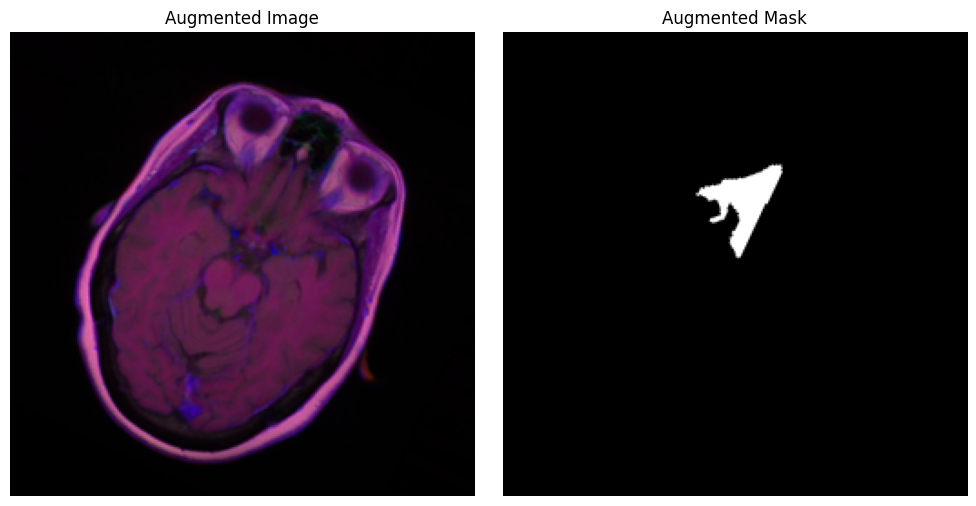

Augmented Image shape: (256, 256, 3), dtype: <dtype: 'float32'>
Augmented Mask shape: (256, 256, 1), dtype: <dtype: 'float32'>


In [44]:
# Apply augmentation to the preprocessed example
augmented_image, augmented_mask = augment_data(preprocessed_image, preprocessed_mask)

# Visualize the augmented image and mask
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(augmented_image)
axes[0].set_title('Augmented Image')
axes[0].axis('off')

axes[1].imshow(augmented_mask, cmap='gray')
axes[1].set_title('Augmented Mask')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Augmented Image shape: {augmented_image.shape}, dtype: {augmented_image.dtype}")
print(f"Augmented Mask shape: {augmented_mask.shape}, dtype: {augmented_mask.dtype}")

##Create Data Generators





In [46]:
IMG_WIDTH = 256
IMG_HEIGHT = 256
IMG_CHANNELS = 3
BATCH_SIZE = 8

def load_and_preprocess_tf(image_path, mask_path):
    # Need to wrap the Python function for TF Dataset
    def _preprocess_py_function(image_path_tensor, mask_path_tensor):
        # image_path_tensor and mask_path_tensor are tf.Tensor objects with dtype=tf.string
        # Convert them to Python strings using .numpy().decode('utf-8')
        image_path_str = image_path_tensor.numpy().decode('utf-8')
        mask_path_str = mask_path_tensor.numpy().decode('utf-8')

        image, mask = preprocess_image_mask(
            image_path_str,
            mask_path_str,
            target_size=(IMG_HEIGHT, IMG_WIDTH)
        )
        return image, mask

    image, mask = tf.py_function(
        _preprocess_py_function,
        [image_path, mask_path],
        [tf.float32, tf.float32]
    )
    # Ensure shapes are fixed after tf.py_function
    image.set_shape([IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS])
    # The preprocess_image_mask function already adds a channel dimension to the mask,
    # so we just need to set the shape here.
    mask.set_shape([IMG_HEIGHT, IMG_WIDTH, 1]) # Corrected shape for mask
    return image, mask

def augment_tf(image, mask):
    # Need to wrap the Python function for TF Dataset
    def _augment_py_function(image_np, mask_np):
        aug_image, aug_mask = augment_data(image_np, mask_np)
        return aug_image, aug_mask

    # Use tf.numpy_function because augment_data internally uses numpy() conversion
    aug_image, aug_mask = tf.numpy_function(
        _augment_py_function,
        [image, mask],
        [tf.float32, tf.float32]
    )
    # Ensure shapes are fixed after tf.numpy_function. Mask now has a channel dimension.
    aug_image.set_shape([IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS])
    aug_mask.set_shape([IMG_HEIGHT, IMG_WIDTH, 1]) # Corrected shape for augmented mask
    return aug_image, aug_mask


def create_dataset(image_paths, mask_paths, augment=False, shuffle_buffer_size=1000):
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    dataset = dataset.shuffle(buffer_size=shuffle_buffer_size) # Shuffle paths initially
    dataset = dataset.map(load_and_preprocess_tf, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        dataset = dataset.map(augment_tf, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

# Create training and validation datasets
train_dataset = create_dataset(train_image_paths, train_mask_paths, augment=True)
val_dataset = create_dataset(val_image_paths, val_mask_paths, augment=False)

print("Training and Validation tf.data.Dataset created.")

# Verify the datasets
for image, mask in train_dataset.take(1):
    print(f"Train Batch Image shape: {image.shape}, dtype: {image.dtype}")
    print(f"Train Batch Mask shape: {mask.shape}, dtype: {mask.dtype}")

for image, mask in val_dataset.take(1):
    print(f"Validation Batch Image shape: {image.shape}, dtype: {image.dtype}")
    print(f"Validation Batch Mask shape: {mask.shape}, dtype: {mask.dtype}")

Training and Validation tf.data.Dataset created.
Train Batch Image shape: (8, 256, 256, 3), dtype: <dtype: 'float32'>
Train Batch Mask shape: (8, 256, 256, 1), dtype: <dtype: 'float32'>
Validation Batch Image shape: (8, 256, 256, 3), dtype: <dtype: 'float32'>
Validation Batch Mask shape: (8, 256, 256, 1), dtype: <dtype: 'float32'>


## Model Architecture

In [34]:
# Uninstall the incompatible segmentation_models library
!pip uninstall -y segmentation-models

# Install keras-unet-collection, a U-Net library compatible with newer TensorFlow versions
!pip install keras-unet-collection

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 4.4 MB/s eta 0:00:00


In [47]:
import tensorflow as tf
from tensorflow import keras
from keras_unet_collection import models, losses # Import the new library

In [48]:

BACKBONE = 'ResNet50'
model_input_shape = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
num_classes = 1

filter_num = [32, 64, 128, 256, 512]

model = models.unet_2d(
    input_size=model_input_shape, # Corrected keyword from input_shape to input_size
    filter_num=filter_num,
    n_labels=num_classes,
    activation='ReLU',
    output_activation='Sigmoid',
    batch_norm=True,
    pool=True,
    unpool=True,
    name='unet'
)

print(f"U-Net model with {BACKBONE} like backbone created using keras_unet_collection.")
model.summary()

U-Net model with ResNet50 like backbone created using keras_unet_collection.


Model: "unet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down0_0        │ (None, 256, 256,  │        864 │ input_layer_1[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down0_0_bn     │ (None, 256, 256,  │        128 │ unet_down0_0[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down0_0_activ… │ (None, 256, 256,  │          0 │ unet_down0_0_bn[… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down0_1        │ (None, 256, 256,  │      9,216 │ unet_down0_0_act… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down0_1_bn     │ (None, 256, 256,  │        128 │ unet_down0_1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down0_1_activ… │ (None, 256, 256,  │          0 │ unet_down0_1_bn[… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_encode_… │ (None, 128, 128,  │          0 │ unet_down0_1_act… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_conv_0   │ (None, 128, 128,  │     18,432 │ unet_down1_encod… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_conv_0_… │ (None, 128, 128,  │        256 │ unet_down1_conv_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_conv_0_… │ (None, 128, 128,  │          0 │ unet_down1_conv_… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_conv_1   │ (None, 128, 128,  │     36,864 │ unet_down1_conv_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_conv_1_… │ (None, 128, 128,  │        256 │ unet_down1_conv_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_conv_1_… │ (None, 128, 128,  │          0 │ unet_down1_conv_… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down2_encode_… │ (None, 64, 64,    │          0 │ unet_down1_conv_… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down2_conv_0   │ (None, 64, 64,    │     73,728 │ unet_down2_encod… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down2_conv_0_… │ (None, 64, 64,    │        512 │ unet_down2_conv_

 Total params: 8,640,769 (32.96 MB)

 Trainable params: 8,633,921 (32.94 MB)

 Non-trainable params: 6,848 (26.75 KB)

In [49]:
from tensorflow import keras
import tensorflow as tf

# Custom Dice Coefficient (F1-score) and IoU (Jaccard Index) for Keras
def dice_coef(y_true, y_pred, smooth=1e-7):
    # y_true should now have a channel dimension from the dataset pipeline
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def iou_coef(y_true, y_pred, smooth=1e-7):
    # y_true should now have a channel dimension from the dataset pipeline
    intersection = tf.reduce_sum(tf.math.abs(y_true * y_pred), axis=[1,2,3]) # Sum over H, W, C
    union = tf.reduce_sum(y_true, axis=[1,2,3]) + tf.reduce_sum(y_pred, axis=[1,2,3]) - intersection
    return tf.reduce_mean( (intersection + smooth) / (union + smooth), axis=0)

# Define a custom combined loss function
def combined_dice_bce_loss(y_true, y_pred):
    dice_loss_val = 1 - dice_coef(y_true, y_pred)
    # BinaryCrossentropy will now receive y_true with channel dim (H, W, 1)
    bce_loss_val = tf.keras.losses.BinaryCrossentropy(from_logits=False)(y_true, y_pred)
    return dice_loss_val + bce_loss_val

# Define metrics and loss functions
optim = keras.optimizers.Adam(learning_rate=0.0001)

# Use the combined custom loss function
total_loss = combined_dice_bce_loss


metrics = [
    iou_coef,
    dice_coef
]

# Compile the model
model.compile(optimizer=optim, loss=total_loss, metrics=metrics)

print("U-Net model compiled with Adam optimizer, Dice+BCE loss, and IoU/Dice metrics.")

U-Net model compiled with Adam optimizer, Dice+BCE loss, and IoU/Dice metrics.


## Train the Model

In [50]:
EPOCHS = 20

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)
    ]
)

print("Model training complete.")

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


354/354 ━━━━━━━━━━━━━━━━━━━━ 203s 496ms/step - dice_coef: 0.0253 - iou_coef: 0.0114 - loss: 1.2380 - val_dice_coef: 0.0294 - val_iou_coef: 0.0131 - val_loss: 1.1864 - learning_rate: 1.0000e-04
Epoch 2/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 171s 484ms/step - dice_coef: 0.0335 - iou_coef: 0.0142 - loss: 1.1167 - val_dice_coef: 0.0363 - val_iou_coef: 0.0152 - val_loss: 1.1046 - learning_rate: 1.0000e-04
Epoch 3/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 171s 484ms/step - dice_coef: 0.0448 - iou_coef: 0.0176 - loss: 1.0705 - val_dice_coef: 0.0480 - val_iou_coef: 0.0190 - val_loss: 1.0806 - learning_rate: 1.0000e-04
Epoch 4/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 169s 476ms/step - dice_coef: 0.0573 - iou_coef: 0.0216 - loss: 1.0378 - val_dice_coef: 0.0626 - val_iou_coef: 0.0218 - val_loss: 1.0569 - learning_rate: 1.0000e-04
Epoch 5/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 170s 479ms/step - dice_coef: 0.0722 - iou_coef: 0.0255 - loss: 1.0096 - val_dice_coef: 0.0711 - val_iou_coef: 0.0269 - val_loss: 1.0202 - learning_rate: 1.

## Model Prediction, Evaluation, and Visualization

In [51]:
# Create the test dataset (no augmentation for testing)
test_dataset = create_dataset(test_image_paths, test_mask_paths, augment=False)

print("Test tf.data.Dataset created.")

# Verify the test dataset
for image, mask in test_dataset.take(1):
    print(f"Test Batch Image shape: {image.shape}, dtype: {image.dtype}")
    print(f"Test Batch Mask shape: {mask.shape}, dtype: {mask.dtype}")

Test tf.data.Dataset created.
Test Batch Image shape: (8, 256, 256, 3), dtype: <dtype: 'float32'>
Test Batch Mask shape: (8, 256, 256, 1), dtype: <dtype: 'float32'>


### 2. Evaluate the Model



In [52]:
print("Evaluating model on test data...")

test_results = model.evaluate(test_dataset)

print("Test Loss: {:.4f}".format(test_results[0]))
print("Test IoU Coefficient: {:.4f}".format(test_results[1]))
print("Test Dice Coefficient: {:.4f}".format(test_results[2]))

Evaluating model on test data...
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step - dice_coef: 0.1385 - iou_coef: 0.0389 - loss: 0.9187
Test Loss: 0.9187
Test IoU Coefficient: 0.0389
Test Dice Coefficient: 0.1385


### 3. Visualize Predictions


Displaying sample predictions:
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


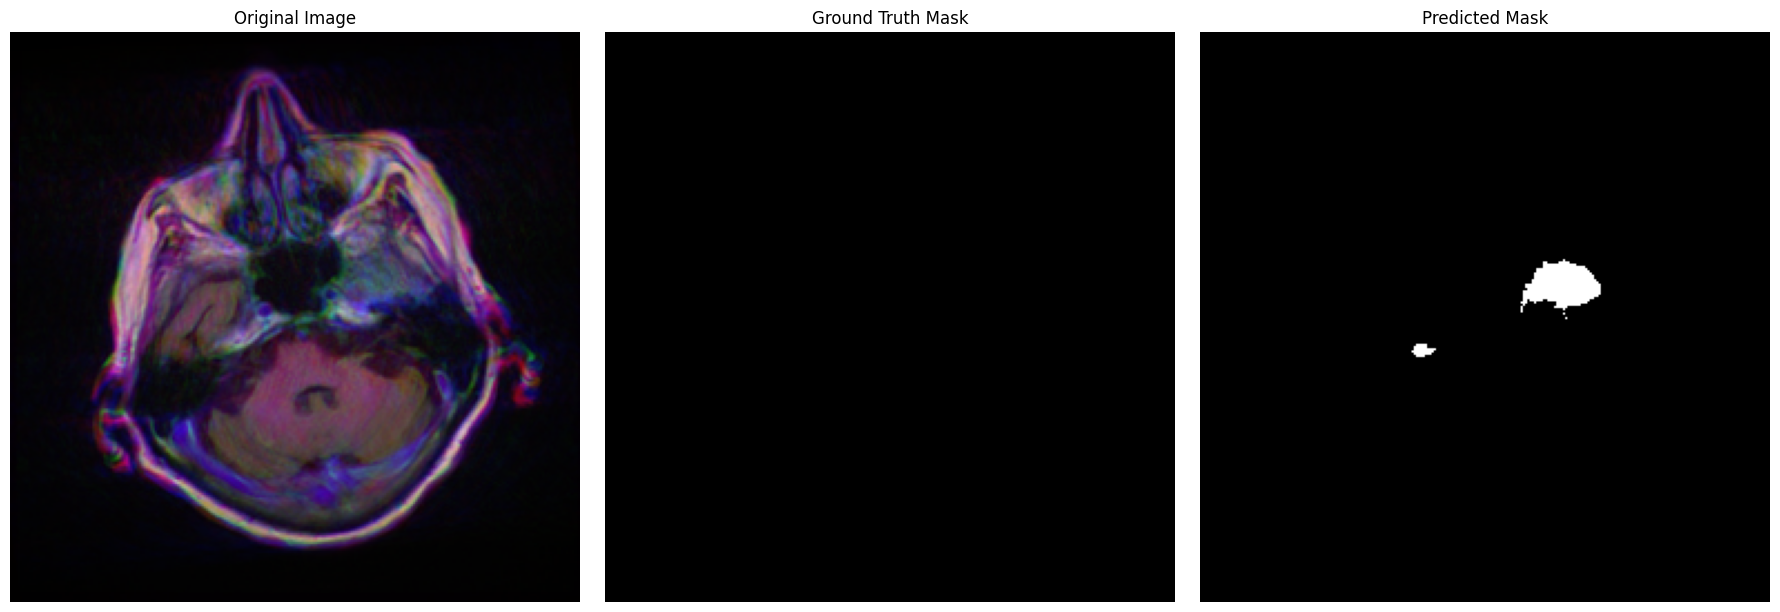

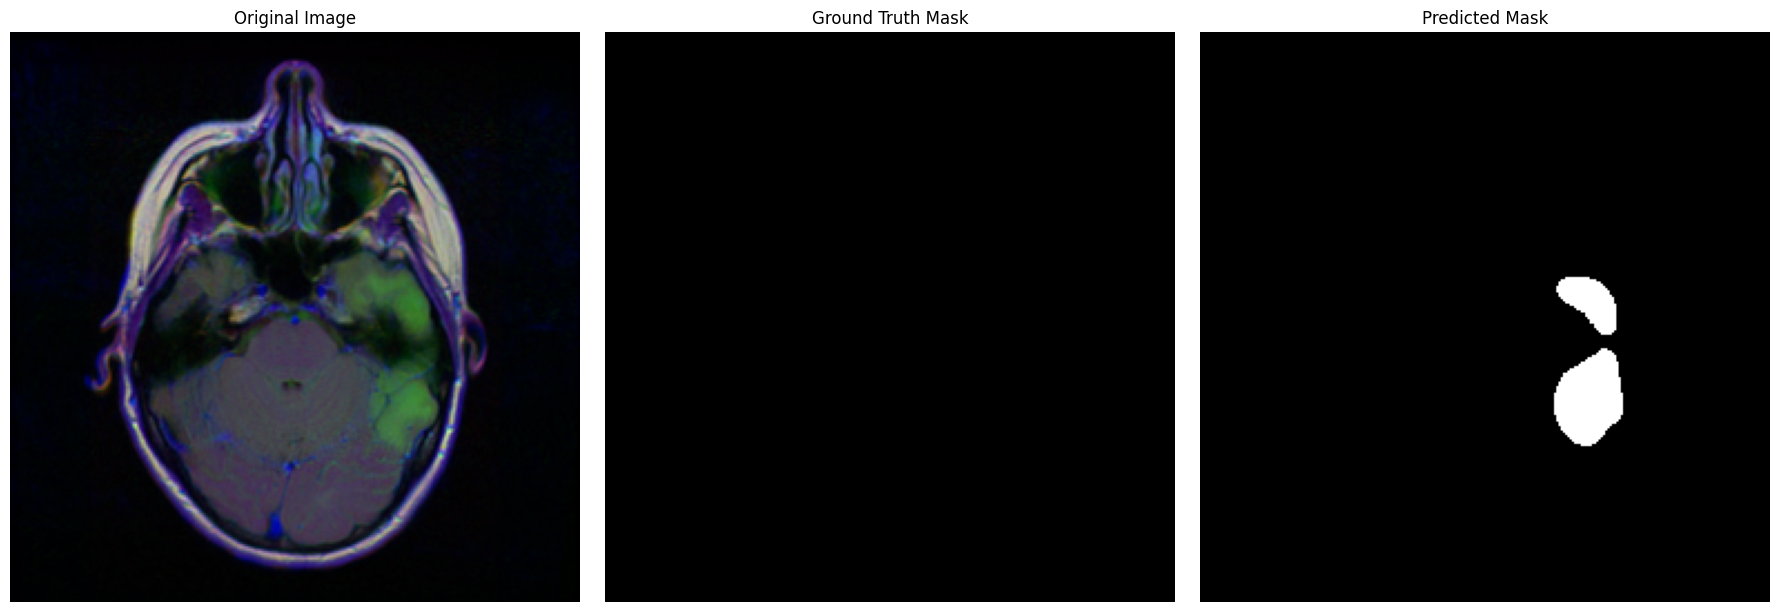

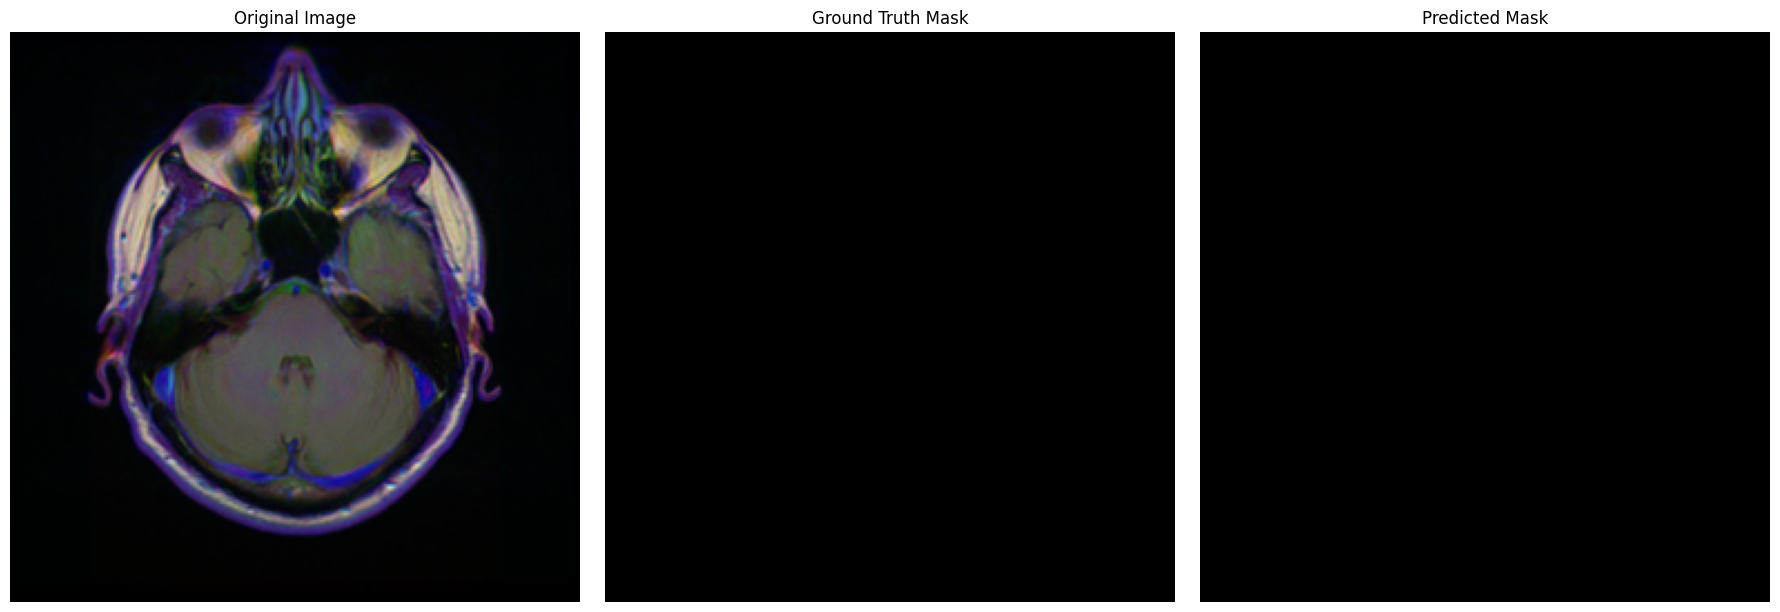

In [53]:
import matplotlib.pyplot as plt

def display_predictions(dataset, num_examples=5):
    """
    Displays original images, ground truth masks, and predicted masks.
    """
    for i, (image_batch, true_mask_batch) in enumerate(dataset.take(1)):
        if i >= num_examples: # Only take a few examples from the first batch
            break

        predicted_mask_batch = model.predict(image_batch)

        for j in range(min(num_examples, BATCH_SIZE)): # Iterate over items in the batch
            fig, axes = plt.subplots(1, 3, figsize=(18, 6))

            # Original Image
            axes[0].imshow(image_batch[j])
            axes[0].set_title('Original Image')
            axes[0].axis('off')

            # Ground Truth Mask
            axes[1].imshow(true_mask_batch[j].numpy().squeeze(), cmap='gray')
            axes[1].set_title('Ground Truth Mask')
            axes[1].axis('off')

            # Predicted Mask
            # Apply threshold to the predicted probabilities to get binary mask
            predicted_binary_mask = (predicted_mask_batch[j] > 0.5).astype(float)
            axes[2].imshow(predicted_binary_mask.squeeze(), cmap='gray')
            axes[2].set_title('Predicted Mask')
            axes[2].axis('off')

            plt.tight_layout()
            plt.show()

print("Displaying sample predictions:")
display_predictions(test_dataset, num_examples=3) # Display 3 examples from the test set

### 4. Plot Training History

Let's visualize the training and validation metrics (loss, IoU, Dice coefficient) over the epochs to observe the model's learning progress.

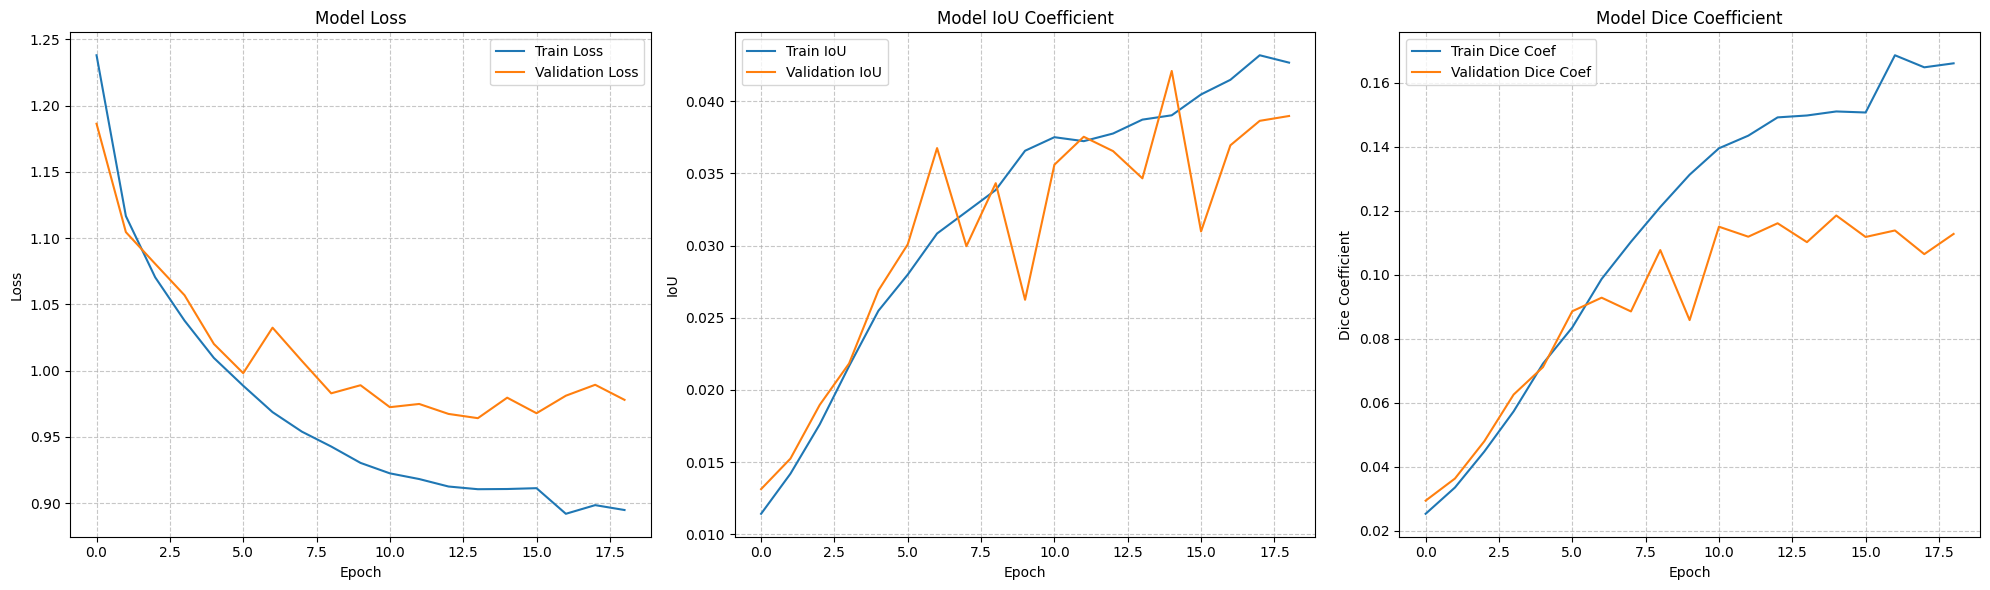

In [54]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Plot training & validation loss values
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title('Model Loss')
    axes[0].set_ylabel('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # Plot training & validation IoU values
    axes[1].plot(history.history['iou_coef'], label='Train IoU')
    axes[1].plot(history.history['val_iou_coef'], label='Validation IoU')
    axes[1].set_title('Model IoU Coefficient')
    axes[1].set_ylabel('IoU')
    axes[1].set_xlabel('Epoch')
    axes[1].legend(loc='upper left')
    axes[1].grid(True, linestyle='--', alpha=0.7)

    # Plot training & validation Dice Coefficient values
    axes[2].plot(history.history['dice_coef'], label='Train Dice Coef')
    axes[2].plot(history.history['val_dice_coef'], label='Validation Dice Coef')
    axes[2].set_title('Model Dice Coefficient')
    axes[2].set_ylabel('Dice Coefficient')
    axes[2].set_xlabel('Epoch')
    axes[2].legend(loc='upper left')
    axes[2].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

plot_training_history(history)